In [ ]:
from google.colab import files
upload=files.upload()

Saving Groundwater_dataset.csv to Groundwater_dataset.csv


In [ ]:
model_upload=files.upload()

Saving groundwater_rf_model.joblib to groundwater_rf_model.joblib


In [ ]:
import pandas as pd
import joblib
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

In [ ]:
model=joblib.load("groundwater_rf_model.joblib")

In [ ]:
model

RandomForestClassifier(criterion='entropy', max_depth=10, n_estimators=150,
                       random_state=42)

In [ ]:
df=pd.read_csv("Groundwater_dataset.csv")

In [ ]:
df.head()

,LAT,LONG,WL_MBGL,elevation,potential,slope,soil_subsurface,soil_surface,tpi
0,30.47000,73.08917,6.127041,157,1,0.000000,7,7,-0.889590
1,30.61306,73.00361,7.460307,170,1,1.077566,7,7,3.309148
2,30.30500,72.80083,7.578483,152,1,2.147576,7,7,1.037855
3,30.27167,72.85556,8.816340,150,1,2.142427,7,7,-0.138801
4,30.36000,72.99472,10.818571,156,1,0.927410,7,7,-0.441640


In [ ]:
df_ready=df.drop(["potential","WL_MBGL"],axis=1)

In [ ]:
df_ready.head()

,LAT,LONG,elevation,slope,soil_subsurface,soil_surface,tpi
0,30.47000,73.08917,157,0.000000,7,7,-0.889590
1,30.61306,73.00361,170,1.077566,7,7,3.309148
2,30.30500,72.80083,152,2.147576,7,7,1.037855
3,30.27167,72.85556,150,2.142427,7,7,-0.138801
4,30.36000,72.99472,156,0.927410,7,7,-0.441640


In [ ]:
lat_min,lat_max=df["LAT"].min(),df["LAT"].max()
long_min,long_max=df["LONG"].min(),df["LONG"].max()

In [ ]:
grid_size=150
lat_array=np.linspace(lat_min,lat_max,grid_size)
long_array=np.linspace(long_min,long_max,grid_size)


In [ ]:
lat_grid,long_grid=np.meshgrid(lat_array,long_array)

In [ ]:
grid_df=pd.DataFrame({"LAT":lat_grid.ravel(),"LONG":long_grid.ravel()})

In [ ]:
grid_df["LONG"].value_counts(),df["LONG"].value_counts()

(LONG
 71.503000    150
 71.519752    150
 71.536503    150
 71.553255    150
 71.570007    150
             ... 
 73.931993    150
 73.948745    150
 73.965497    150
 73.982248    150
 73.999000    150
 Name: count, Length: 150, dtype: int64,
 LONG
 72.63833    7
 73.28056    4
 73.29000    4
 73.24556    4
 72.87861    3
            ..
 72.16222    1
 71.93583    1
 71.90889    1
 71.88889    1
 71.60000    1
 Name: count, Length: 2520, dtype: int64)

In [ ]:
grid_coord=grid_df[["LAT","LONG"]].values

In [ ]:

features=df_ready.columns.drop(["LAT","LONG"])
features


Index(['elevation', 'slope', 'soil_subsurface', 'soil_surface', 'tpi'], dtype='object')

In [ ]:
known_coords=df_ready[["LAT","LONG"]].values

In [ ]:
known_coords

array([[30.47      , 73.08917   ],
       [30.61306   , 73.00361   ],
       [30.305     , 72.80083   ],
       ...,
       [31.66918263, 73.91487703],
       [29.1811699 , 72.69913964],
       [29.96342192, 72.29965823]])

In [ ]:
for feature in features:
  known_value=df_ready[feature].values
  grid_df[feature]=griddata(known_coords, known_value, grid_coord,method="nearest")

In [ ]:
grid_df

,LAT,LONG,elevation,slope,soil_subsurface,soil_surface,tpi
0,29.090900,71.503,114.0,2.136470,7.0,7.0,1.356467
1,29.113780,71.503,114.0,2.136470,7.0,7.0,1.356467
2,29.136660,71.503,114.0,2.136470,7.0,7.0,1.356467
3,29.159540,71.503,114.0,2.136470,7.0,7.0,1.356467
4,29.182419,71.503,114.0,2.136470,7.0,7.0,1.356467
...,...,...,...,...,...,...,...
22495,32.408481,73.999,224.0,2.194925,7.0,7.0,0.536278
22496,32.431360,73.999,222.0,2.988654,7.0,7.0,0.637224
22497,32.454240,73.999,225.0,4.754968,7.0,7.0,3.343849
22498,32.477120,73.999,225.0,4.754968,7.0,7.0,3.343849


In [ ]:
X_new=grid_df[features]

In [ ]:
grid_df["potential"]=model.predict_proba(X_new)[:,1]

In [ ]:
matrix_probability = grid_df['potential'].values.reshape(lat_grid.shape)

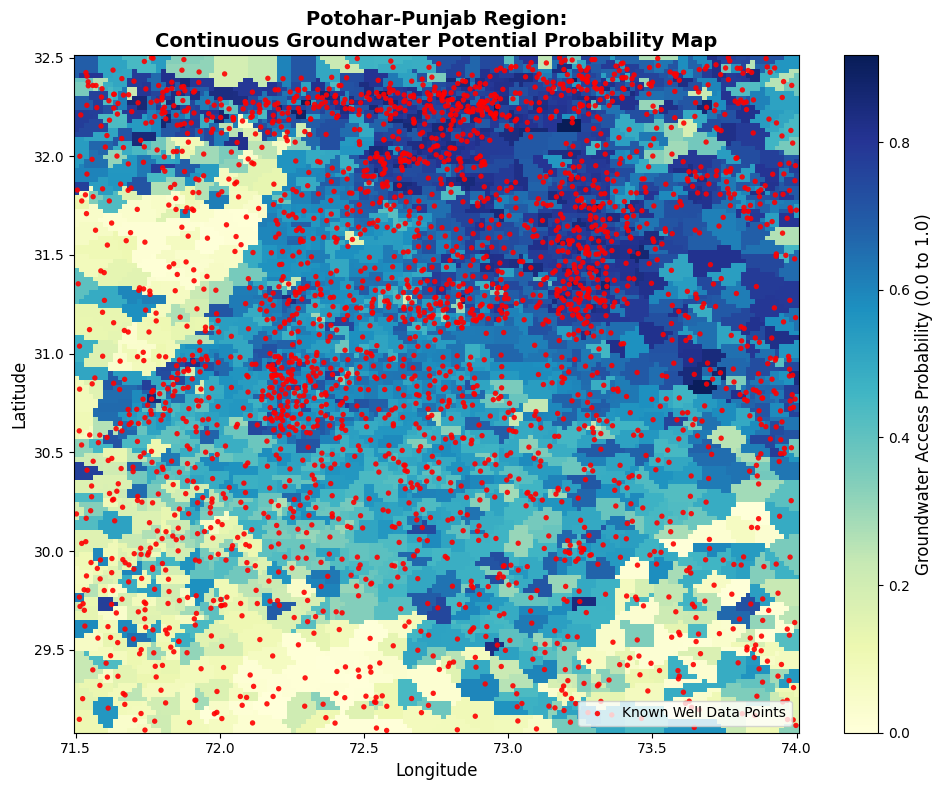

In [ ]:
plt.figure(figsize=(10, 8))
contour = plt.pcolormesh(long_grid, lat_grid, matrix_probability, cmap='YlGnBu', shading='auto')
cbar = plt.colorbar(contour)
cbar.set_label('Groundwater Access Probability (0.0 to 1.0)', fontsize=12)
plt.scatter(df['LONG'], df['LAT'], c='red', s=15, alpha=0.9, edgecolor='none', label='Known Well Data Points')
plt.title('Potohar-Punjab Region:\nContinuous Groundwater Potential Probability Map', fontsize=14, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(loc='lower right')
#plt.grid(True, linestyle='--', alpha=0.9)
plt.savefig("groundwater_potential_map.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [ ]:
import sys
print(f"Pandas:     {pd.__version__}")
print(f"Joblib:     {joblib.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"Matplotlib: {sys.modules["matplotlib"].__version__}")
print(f"SciPy:      {sys.modules['scipy'].__version__}")

Pandas:     2.2.2
Joblib:     1.5.3
NumPy:      2.0.2
Matplotlib: 3.10.0
SciPy:      1.16.3
